<a href="https://colab.research.google.com/github/SouvickC/time_series_prediction_project/blob/main/2_BaselineModel/Time_Series_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss

In [6]:
# !pip install sktime[all_extras] -qq

In [7]:
DATASET_PATH = Path("/content/drive/MyDrive/Colab Notebooks/tdcsfog")
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"

In [8]:
def load_file(file_path: Path) -> tuple[np.ndarray, float]:

    # Load the data into a numpy ndarray
    with open(file_path, "rb") as infile:
        arr = np.load(infile)

    # Extract the accelerometer data as the input features
    features = arr[:, 1:4]

    # Extract the labels
    labels = arr[:, 4:]
    labels = np.max(labels, axis=-1)
    return features, np.any(labels).astype(float)

In [9]:
loaded_arr = np.load("/content/drive/MyDrive/Colab Notebooks/tdcsfog/train/003f117e14_0000.npy")
print(loaded_arr[0])

dftrain = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tdcsfog/train.csv')
dftrain.head()

[ 0.         -9.5339393   0.56632163 -1.41352531  0.          0.
  0.        ]


,file_name,label
0,76c7edf878_0004.npy,1.0
1,e7b5afe544_0014.npy,1.0
2,76c7edf878_0011.npy,1.0
3,2a9faf5644_0000.npy,0.0
4,5a70242f37_0002.npy,1.0


In [10]:
X_list = []
y_list = []

for fpath in tqdm(TRAIN_PATH.iterdir(), desc="Loading all rows from all files"):
    if not fpath.is_file() or fpath.suffix != ".npy":
        continue

    data = np.load(fpath)              # shape: (N, D), e.g., (1280, 6)
    X_list.append(data[:, 1:4])        # 3 feature columns per row, shape: (N, 3)

    labels = np.max(data[:, 4:], axis=1)  # e.g., max across label columns per row, shape: (N,)
    y_list.append(labels)

# Now concatenate all rows
X_train = np.vstack(X_list)           # shape: (total_rows, 3)
y_train = np.hstack(y_list)           # shape: (total_rows,)

print("Final shapes:", X_train.shape, y_train.shape)

Loading all rows from all files: 4136it [01:08, 60.13it/s] 


Final shapes: (5294080, 3) (5294080,)


In [11]:
X_list1 = []
y_list1 = []

for fpath in tqdm(TEST_PATH.iterdir(), desc="Loading all rows from all files"):
    if not fpath.is_file() or fpath.suffix != ".npy":
        continue

    data = np.load(fpath)              # shape: (N, D), e.g., (1280, 6)
    X_list1.append(data[:, 1:4])        # 3 feature columns per row, shape: (N, 3)

    labels = np.max(data[:, 4:], axis=1)  # e.g., max across label columns per row, shape: (N,)
    y_list1.append(labels)

# Now concatenate all rows
X_test = np.vstack(X_list1)           # shape: (total_rows, 3)
y_test = np.hstack(y_list1)           # shape: (total_rows,)

print("Final shapes:", X_test.shape, y_test.shape)

Loading all rows from all files: 960it [00:11, 82.94it/s] 

Final shapes: (1228800, 3) (1228800,)


In [12]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5294080, 3), (5294080,), (1228800, 3), (1228800,))

In [13]:
model = RandomForestClassifier(n_estimators=50, max_depth=10)

In [14]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50)

In [15]:
 y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

y_pred
print(accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))


0.7516609700520833
[[821837  96062]
 [209097 101804]]
0.5145098197770208
0.32744828739695275
0.40019891227221893


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.80      0.90      0.84    917899
         1.0       0.51      0.33      0.40    310901

    accuracy                           0.75   1228800
   macro avg       0.66      0.61      0.62   1228800
weighted avg       0.73      0.75      0.73   1228800



<Figure size 600x500 with 0 Axes>

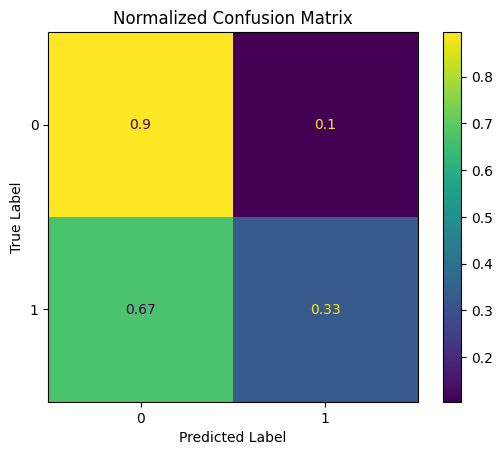

In [23]:
cm = confusion_matrix(y_test, y_pred, normalize='true')  # row-wise normalization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 5))
disp.plot(cmap='viridis', colorbar=True)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()